<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_1/REJECTION_cauchy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [18]:
# Algoritmo de muestreo por rechazo

def rejection(target_pdf, envelope_pdf, num_samples, k, a, b, c, d):
  samples = []
  accepted_samples = []
  rejected_samples = []

  for i in range(num_samples):
      # Obtenermos muestras de la propuesta usando el método de la transformada inversa
      x_proposal = inverse_envelope_pdf(np.random.rand(), c, d)

      u = k * envelope_pdf(x_proposal, c, d) * rng.random()

      if u < target_pdf(x_proposal, a, b) and x_proposal > 0:
          accepted_samples.append(x_proposal)
      else:
          rejected_samples.append(x_proposal)

  accepted_samples = np.array(accepted_samples)
  rejected_samples = np.array(rejected_samples)

  return accepted_samples, rejected_samples


In [19]:
a = 5
b = 2
c = (a - 1) / b
d = (np.sqrt(2 * a - 1)) / b


In [20]:
# Definimos la distribución objetivo
def target_pdf(x, a, b):
    return x ** (a - 1) * np.exp(- x * b)

# Definimos la distribución de propuesta
def envelope_pdf(x, c, d):
    return 1 / (1 + ((x - c) / d) ** 2)

# Inversa de la propuesta (para obtener muestras)
def inverse_envelope_pdf(x, c, d):
    return c + d * np.tan(np.pi * (x - 1 / 2))

In [21]:
# Determinamos la constante k

# Encontrar el rango de x para evaluar las funciones
x_range = np.linspace(0.001, 10, 1000) # Ajustado para que x sea positivo

# Calcular la relación objetivo/envolvente
ratio = target_pdf(x_range, a, b) / envelope_pdf(x_range, c, d)

# k debe ser mayor o igual al máximo de esta relación
k = np.max(ratio)

/tmp/ipykernel_3976/2646004327.py:3: RuntimeWarning: overflow encountered in exp
  return x ** (a - 1) * np.exp(- x * b)
/tmp/ipykernel_3976/2646004327.py:3: RuntimeWarning: overflow encountered in scalar multiply
  return x ** (a - 1) * np.exp(- x * b)


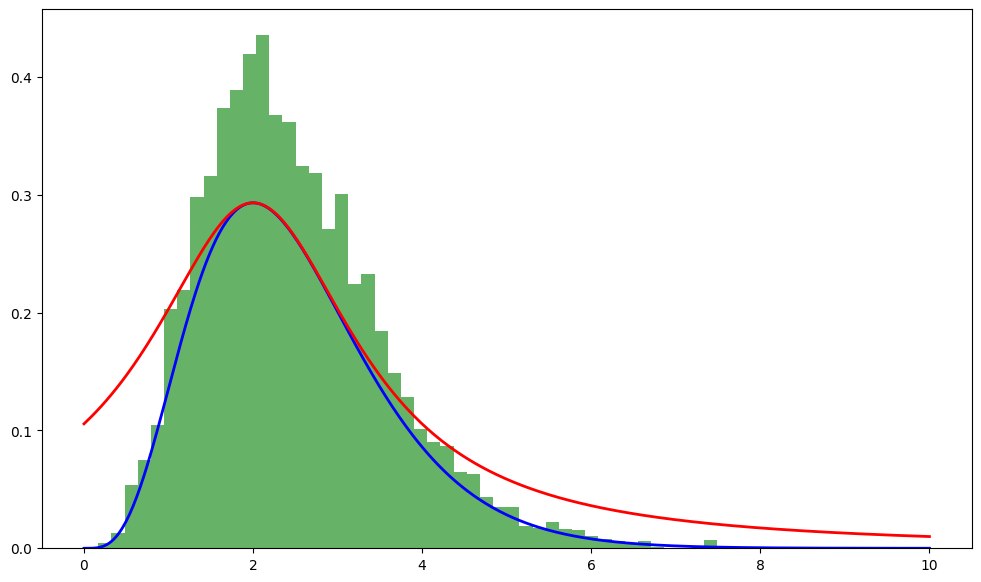

In [22]:
# Establecemos una semilla para la replicabilidad de la imagen
rng = np.random.default_rng(1)

# Generamos las muestras a partir de nuestra función
accepted_samples, rejected_samples = rejection(target_pdf, envelope_pdf, 10000, k, a, b, c, d)

# Visualizamos los resultados
plt.figure(figsize=(12, 7))
x_plot = np.linspace(0.001, 10, 500) # Ajustado para que x sea positivo

# Graficamos la distribución objetivo
plt.plot(x_plot, target_pdf(x_plot, a, b), color='blue', linewidth=2)

# Graficamos la envolvente escalada (k * envolvente_pdf)
plt.plot(x_plot, k * envelope_pdf(x_plot, c, d), color='red', linewidth=2)

# Histograma de las muestras aceptadas
plt.hist(accepted_samples, bins=50, density=True, alpha=0.6, color='green')

plt.ylim(bottom=0)

# Guardamos la imagen
plt.savefig("RECHAZO_cauchy.pdf")

plt.show()


In [23]:
from google.colab import files
files.download("RECHAZO_cauchy.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>